In [1]:
pip install pandas plotly nbformat nbclient ipywidgets matplotlib "urllib3<2"

You should consider upgrading via the '/Users/stripura/Desktop/ocp-workload-analysis/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np
import json
import os
import plotly.express as px
import plotly.graph_objects as go

# --- 1. CONFIGURATION & ENVIRONMENT SETUP ---
# Fetch paths from environment variables or default to current directory
config_dir = os.getenv('CONFIG_DIR', './configs')
data_dir = os.getenv('DATA_DIR', './sample_data')

# Construct full file paths
workload_data_path = os.path.join(data_dir, 'k8s_workload_inventory.csv')
complexity_cfg_path = os.path.join(config_dir, 'workload_complexity_config.json')
migration_cfg_path = os.path.join(config_dir, 'migration_config.json')

print(f"📂 Loading data from: {data_dir}")
print(f"⚙️ Loading configs from: {config_dir}")

# --- 2. LOAD DATA & CONFIGS ---
try:
    df = pd.read_csv(workload_data_path)
    
    with open(complexity_cfg_path) as f:
        comp_cfg = json.load(f)
        
    with open(migration_cfg_path) as f:
        mig_cfg = json.load(f)
except FileNotFoundError as e:
    print(f"❌ Critical Error: Could not find file. {e}")
    raise

# Data Cleaning: Handle missing values and convert Milli/MiB to standard numbers
df['CPU_Request_Milli'] = pd.to_numeric(df['CPU_Request_Milli'], errors='coerce').replace(-1, 0).fillna(0)
df['Mem_Request_MiB'] = pd.to_numeric(df['Mem_Request_MiB'], errors='coerce').replace(-1, 0).fillna(0)

# --- 3. CALCULATE COMPLEXITY SCORE ---
def calculate_workload_score(row, cfg):
    w = cfg['weights']
    res = cfg['resource_intensity']
    score = 0
    
    # Infrastructure Gravity logic
    if str(row['Storage_Complexity']).upper() == 'RWX': 
        score += w['infrastructure_gravity']['storage_rwx_shared']
    if str(row['Host_Network']).capitalize() == 'Yes': 
        score += w['infrastructure_gravity']['host_network_enabled']
    if str(row['Privileged']).capitalize() == 'Yes': 
        score += w['infrastructure_gravity']['privileged_mode']
    if row['Additional_Networks'] > 0: 
        score += w['infrastructure_gravity']['additional_networks_multus']
    
    # Resource Intensity (CPU/Memory Buckets)
    if row['CPU_Request_Milli'] >= res['cpu']['high_threshold_milli']: 
        score += res['cpu']['points']['high']
    if row['Mem_Request_MiB'] >= res['memory']['high_threshold_mib']: 
        score += res['memory']['points']['high']
    
    # Reliability Risk (Missing Probes)
    if str(row['Liveness_Probe']).capitalize() == 'No': 
        score += w['reliability_risk']['missing_liveness_probe']
    if str(row['Readiness_Probe']).capitalize() == 'No': 
        score += w['reliability_risk']['missing_readiness_probe']
    
    return min(score, 100)

df['Complexity_Score'] = df.apply(lambda r: calculate_workload_score(r, comp_cfg), axis=1)

# 1. Load the correct config for Scoring
with open('configs/workload_complexity_config.json', 'r') as f:
    w_cfg = json.load(f)

# 2. Updated function to use effort_categories
def assign_tshirt_size(row, config):
    score = row['Complexity_Score']
    # Iterate through the thresholds defined in workload_complexity_config.json
    for category in config['thresholds']['effort_categories']:
        if category['min_score'] <= score <= category['max_score']:
            # Strip the extra text like "(Easy)" to keep labels clean
            return category['label'].split(' ')[0]
    return "Unknown"

# 3. Apply it
df['Complexity_TShirt'] = df.apply(lambda r: assign_tshirt_size(r, w_cfg), axis=1)

print("✅ Using thresholds from workload_complexity_config.json")


📂 Loading data from: ./sample_data
⚙️ Loading configs from: ./configs
✅ Analysis fixed. Using thresholds from workload_complexity_config.json


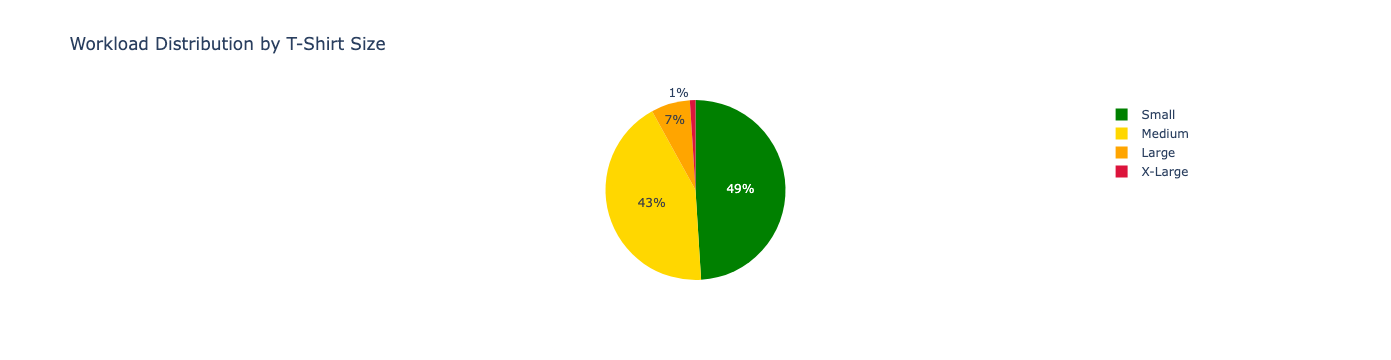

In [34]:
# Pie Chart: T-Shirt Size Distribution
fig_pie = px.pie(df, names='Complexity_TShirt', 
                 title="Workload Distribution by T-Shirt Size",
                 color='Complexity_TShirt',
                 color_discrete_map={
                     'Small': 'green',
                     'Medium': 'gold',
                     'Large': 'orange',
                     'X-Large': 'crimson'
                 },
                 category_orders={"Complexity_TShirt": ["Small", "Medium", "Large", "X-Large"]})
fig_pie.show()


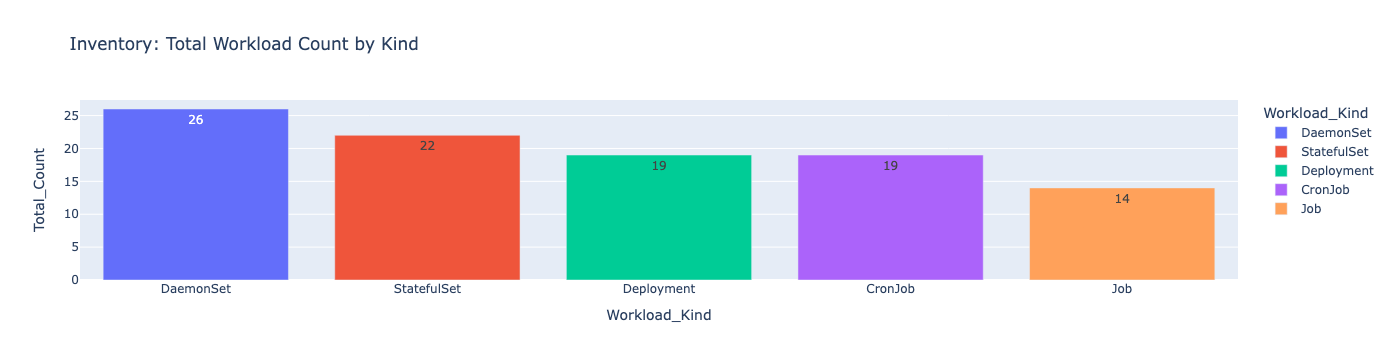

In [35]:
kind_counts = df['Kind'].value_counts().reset_index()
kind_counts.columns = ['Workload_Kind', 'Total_Count']

fig_bar = px.bar(kind_counts, 
                 x='Workload_Kind', 
                 y='Total_Count',
                 color='Workload_Kind',
                 text='Total_Count',
                 title="Inventory: Total Workload Count by Kind")
fig_bar.show()

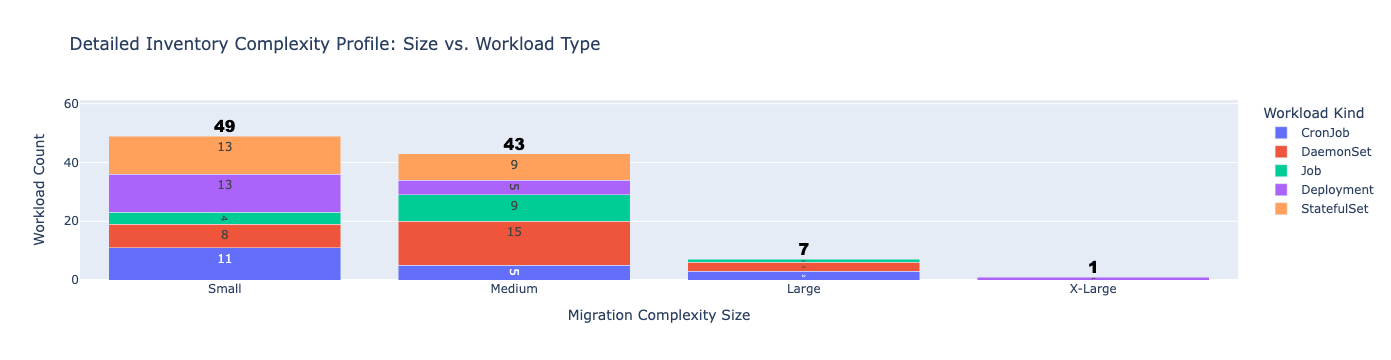

In [36]:
# --- 5. NEW VISUALIZATION: STACKED BAR (T-Shirt Size vs. Kind) ---
import plotly.express as px
import plotly.graph_objects as go

# 1. Prepare data
category_order = ["Small", "Medium", "Large", "X-Large"]
complexity_profile_data = df.groupby(['Complexity_TShirt', 'Kind']).size().reset_index(name='Count')

# 2. Calculate Totals
totals = df.groupby('Complexity_TShirt').size().reindex(category_order).fillna(0).reset_index(name='Total')

# 3. Create the Base Stacked Bar Chart
fig_stacked_profile = px.bar(complexity_profile_data, 
                             x='Complexity_TShirt', 
                             y='Count', 
                             color='Kind',
                             text='Count',
                             title="Detailed Inventory Complexity Profile: Size vs. Workload Type",
                             labels={'Complexity_TShirt': 'Migration Complexity Size', 'Count': 'Workload Count'},
                             category_orders={"Complexity_TShirt": category_order})

# 4. FIX: Apply 'inside' ONLY to the Bar traces
fig_stacked_profile.update_traces(textposition='inside', selector=dict(type='bar'))

# 5. Add the Total Labels on top (Scatter uses 'top center')
fig_stacked_profile.add_trace(go.Scatter(
    x=totals['Complexity_TShirt'], 
    y=totals['Total'], 
    text=totals['Total'].astype(int),
    mode='text',
    textposition='top center',
    textfont=dict(size=16, color='black', family="Arial Black"),
    name='Total Count',
    showlegend=False
))

# 6. Adjust layout for headroom
max_val = totals['Total'].max()
fig_stacked_profile.update_layout(
    yaxis=dict(range=[0, max_val * 1.25]),
    xaxis_title="Migration Complexity Size",
    yaxis_title="Workload Count",
    legend_title="Workload Kind",
    barmode='stack'
)

fig_stacked_profile.show()

In [38]:
print("### TOP 25 EASY WORKLOADS (Low Complexity) ###")

easy_workloads = df.sort_values(
    by=['Complexity_Score', 'Name'], 
    ascending=[True, True]
).head(25)

print(f"✅ Displaying the 25 simplest workloads in the cluster (Wave 1 Candidates).")

# Display with GitOps readiness and a green gradient for the score
display(easy_workloads[[
    'Name', 
    'Namespace', 
    'Kind', 
    'Complexity_Score', 
    'Complexity_TShirt'
]].style.background_gradient(cmap='Greens', subset=['Complexity_Score']))

### TOP 25 EASY WORKLOADS (Low Complexity) ###
✅ Displaying the 25 simplest workloads in the cluster (Wave 1 Candidates).


,Name,Namespace,Kind,Complexity_Score,Complexity_TShirt
26,sample-app-26,logging,DaemonSet,0,Small
42,sample-app-42,backend,StatefulSet,0,Small
66,sample-app-66,database,Job,0,Small
68,sample-app-68,frontend,Job,0,Small
73,sample-app-73,security,CronJob,0,Small
79,sample-app-79,logging,StatefulSet,0,Small
83,sample-app-83,security,DaemonSet,0,Small
87,sample-app-87,logging,Job,0,Small
88,sample-app-88,frontend,DaemonSet,0,Small
90,sample-app-90,security,StatefulSet,0,Small


In [39]:
print("### TOP 25 DIFFICULT WORKLOADS (High Complexity) ###")

# --- TOP 25 MOST DIFFICULT (Global Sort) ---

# Sort by Score DESCENDING across the whole dataframe
difficult_workloads = df.sort_values(
    by=['Complexity_Score', 'Name'], 
    ascending=[False, True]
).head(25)

print(f"🚨 Displaying the 25 most complex workloads in the cluster.")

# Displaying with T-Shirt size so you can see where the 'Very Complex' ends and 'Large' begins
display(difficult_workloads[[
    'Name', 
    'Namespace', 
    'Kind', 
    'Complexity_Score', 
    'Complexity_TShirt',
    'Storage_Complexity',
    'Host_Network',
    'Privileged'
]].style.background_gradient(cmap='Reds', subset=['Complexity_Score']))

### TOP 25 DIFFICULT WORKLOADS (High Complexity) ###
🚨 Displaying the 25 most complex workloads in the cluster.


,Name,Namespace,Kind,Complexity_Score,Complexity_TShirt,Storage_Complexity,Host_Network,Privileged
53,sample-app-53,frontend,Deployment,76,X-Large,RWX,Yes,Yes
85,sample-app-85,frontend,Job,63,Large,RWX,No,Yes
75,sample-app-75,backend,CronJob,53,Large,RWX,Yes,No
34,sample-app-34,frontend,DaemonSet,51,Large,RWO,Yes,No
72,sample-app-72,monitoring,CronJob,50,Large,nan,Yes,Yes
25,sample-app-25,payments,DaemonSet,48,Large,RWX,No,No
27,sample-app-27,payments,CronJob,48,Large,RWX,No,Yes
96,sample-app-96,logging,DaemonSet,48,Large,RWX,No,No
97,sample-app-97,payments,DaemonSet,45,Medium,RWX,Yes,No
3,sample-app-3,frontend,Job,43,Medium,RWO,Yes,No


In [40]:
# --- Capacity Planning Table ---
capacity_table = df.groupby('Complexity_TShirt').agg({
    'Name': 'count',
    'CPU_Request_Milli': 'sum',
    'Mem_Request_MiB': 'sum'
}).reset_index()

# Convert Milli to Cores and MiB to GiB for readability
capacity_table['Total_CPU_Cores'] = capacity_table['CPU_Request_Milli'] / 1000
capacity_table['Total_Mem_GiB'] = capacity_table['Mem_Request_MiB'] / 1024

print("🏢 Target Cluster Capacity Requirements (by T-Shirt Size)")
display(capacity_table[['Complexity_TShirt', 'Name', 'Total_CPU_Cores', 'Total_Mem_GiB']])

🏢 Target Cluster Capacity Requirements (by T-Shirt Size)


,Complexity_TShirt,Name,Total_CPU_Cores,Total_Mem_GiB
0,Large,7,3.5,4.5
1,Medium,43,42.0,72.5
2,Small,49,30.0,81.0
3,X-Large,1,2.0,0.0


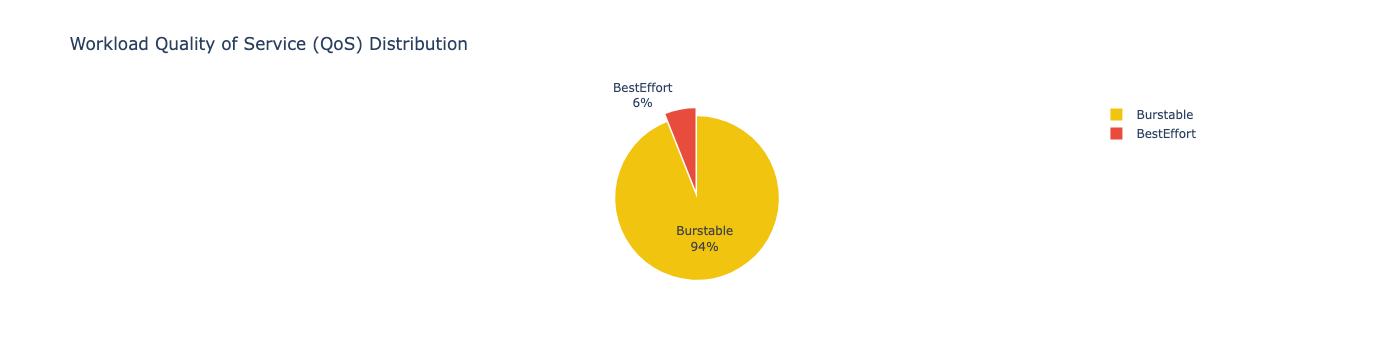

In [41]:
def calculate_qos(row):
    cpu_req = row['CPU_Request_Milli']
    cpu_lim = row['CPU_Limit_Milli']
    mem_req = row['Mem_Request_MiB']
    mem_lim = row['Mem_Limit_MiB']

    # 1. BestEffort: No requests or limits defined
    if cpu_req <= 0 and cpu_lim <= 0 and mem_req <= 0 and mem_lim <= 0:
        return "BestEffort"
    
    # 2. Guaranteed: Requests and Limits are present and EQUAL
    # Note: Limits must be > 0 to be 'Guaranteed'
    if (cpu_req > 0 and cpu_req == cpu_lim) and (mem_req > 0 and mem_req == mem_lim):
        return "Guaranteed"
    
    # 3. Burstable: Everything else
    return "Burstable"

# Apply the calculation
df['QoS_Class'] = df.apply(calculate_qos, axis=1)

# --- QoS Distribution Chart ---
fig_qos = px.pie(df, names='QoS_Class', 
                 title="Workload Quality of Service (QoS) Distribution",
                 color='QoS_Class',
                 color_discrete_map={
                     'Guaranteed': '#2ecc71', # Green (Stable)
                     'Burstable': '#f1c40f',  # Yellow (Standard)
                     'BestEffort': '#e74c3c'  # Red (Risk)
                 })

fig_qos.update_traces(textinfo='percent+label', pull=[0.1, 0, 0])
fig_qos.show()

In [31]:
# --- GitOps Blocker Analysis ---
# Filter for Small/Medium apps that ARE NOT GitOps ready
blockers = df[(df['Complexity_TShirt'].isin(['Small', 'Medium'])) & (df['GitOps_Ready'] == False)]

# Count the reasons
probe_missing = (blockers['Liveness_Probe'] == 'No').sum()
security_blocker = (blockers['Privileged'] == 'Yes').sum()

print(f"📊 GitOps Enablement Report:")
print(f"Total 'Easy' apps blocked from GitOps: {len(blockers)}")
print(f"  - Missing Health Probes: {probe_missing}")
print(f"  - Security/Privileged Blockers: {security_blocker}")

📊 GitOps Enablement Report:
Total 'Easy' apps blocked from GitOps: 53
  - Missing Health Probes: 24
  - Security/Privileged Blockers: 23


In [42]:
import pandas as pd
import json

# Load the Namespace Config
with open('configs/ns_complexity_config.json', 'r') as f:
    ns_cfg = json.load(f)

def analyze_namespaces(df, config):
    w = config['weights']
    
    # 1. Group by Namespace
    ns_groups = df.groupby('Namespace')
    
    ns_results = []
    
    for name, group in ns_groups:
        score = 0
        
        # --- A. Project Density (Number of Apps) ---
        app_count = len(group)
        density_cfg = w['project_density']
        if app_count >= density_cfg['app_count_threshold_high']:
            score += density_cfg['high_density_points']
        elif app_count >= density_cfg['app_count_threshold_medium']:
            score += density_cfg['medium_density_points']
            
        # --- B. Workload Gravity (Presence of Stateful/DaemonSets) ---
        if (group['Kind'] == 'StatefulSet').any():
            score += w['workload_gravity']['has_statefulsets']
        if (group['Kind'] == 'DaemonSet').any():
            score += w['workload_gravity']['has_daemonsets']
            
        # --- C. Storage Complexity (High PVC count) ---
        pvc_count = (group['Storage_Complexity'] != 'None').sum()
        if pvc_count >= w['workload_gravity']['high_pvc_count_threshold']:
            score += w['workload_gravity']['data_heavy_points']

        # --- D. Infrastructure Multiplier (System vs App) ---
        multiplier = config['namespace_types']['application']['effort_multiplier']
        system_prefixes = config['namespace_types']['system']['prefixes']
        if any(name.startswith(p) for p in system_prefixes):
            multiplier = config['namespace_types']['system']['effort_multiplier']
            
        final_score = min(score * multiplier, 100)
        
        # --- E. Assign T-Shirt Size from Thresholds ---
        ns_label = "Small" # Default
        for threshold in config['thresholds']['migration_impact']:
            if threshold['min_score'] <= final_score <= threshold['max_score']:
                ns_label = threshold['label']
                break
        
        ns_results.append({
            'Namespace': name,
            'NS_Score': final_score,
            'NS_Complexity': ns_label,
            'App_Count': app_count,
            'Total_CPU': group['CPU_Request_Milli'].sum(),
            'Total_Mem_GiB': group['Mem_Request_MiB'].sum() / 1024,
            'Action_Required': next((t['action'] for t in config['thresholds']['migration_impact'] if t['label'] == ns_label), "")
        })
        
    return pd.DataFrame(ns_results)

# Run the analysis
ns_df = analyze_namespaces(df, ns_cfg)

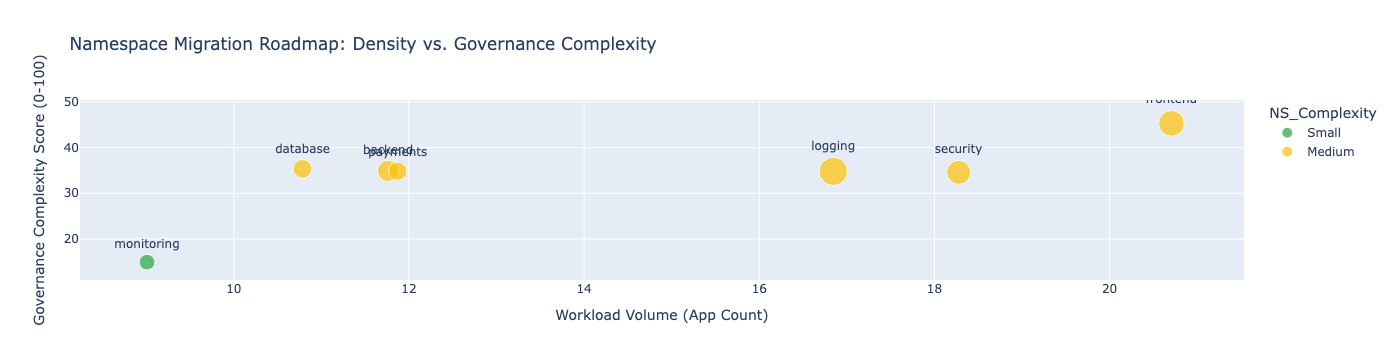

In [50]:
import numpy as np

# Create a copy for plotting to avoid changing your real data
plot_df = ns_df.copy()

# Add a tiny bit of random noise so overlapping bubbles become visible
# 0.2 is small enough to not change the meaning but large enough to see the gap
plot_df['App_Count_Jitter'] = plot_df['App_Count'] + np.random.uniform(-0.3, 0.3, len(plot_df))
plot_df['NS_Score_Jitter'] = plot_df['NS_Score'] + np.random.uniform(-0.5, 0.5, len(plot_df))

fig_ns = px.scatter(plot_df, 
                    x='App_Count_Jitter',  # Use jittered X
                    y='NS_Score_Jitter',    # Use jittered Y
                    size='Total_Mem_GiB', 
                    color='NS_Complexity',
                    hover_name='Namespace', # This will show which name is which
                    text='Namespace',       # OPTIONAL: This adds the name next to the bubble
                    title="Namespace Migration Roadmap: Density vs. Governance Complexity",
                    color_discrete_map=color_map,
                    category_orders={"NS_Complexity": ["Small", "Medium", "Large", "X-Large"]})

# Make the labels look nice
fig_ns.update_traces(textposition='top center')
fig_ns.update_layout(
    xaxis_title="Workload Volume (App Count)",
    yaxis_title="Governance Complexity Score (0-100)"
)

fig_ns.show()

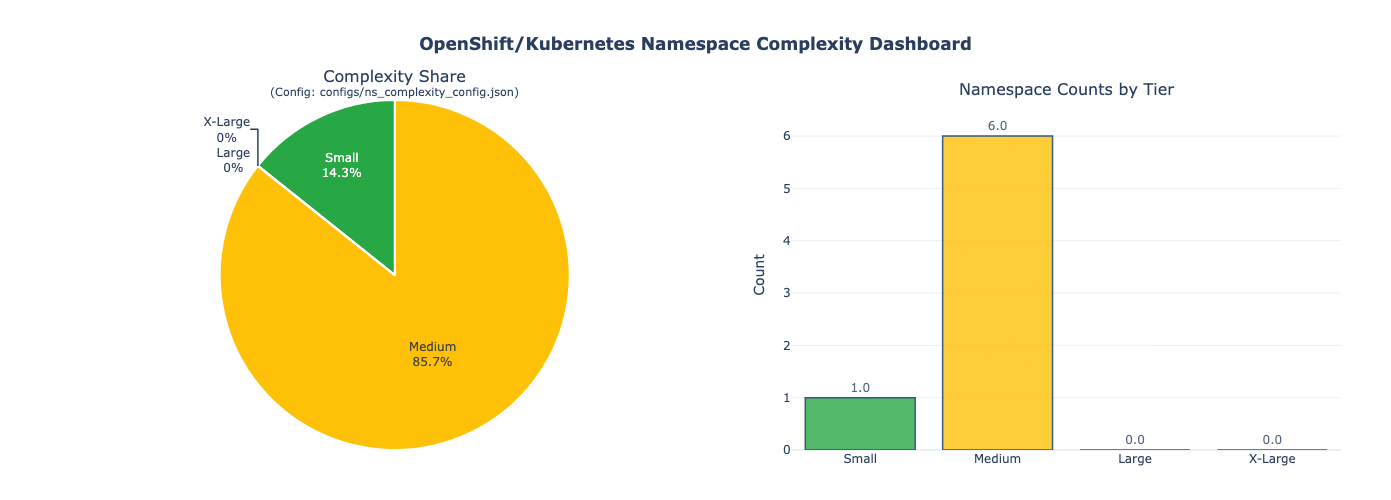

In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Prepare Data from your ns_df
ns_counts = ns_df['NS_Complexity'].value_counts().reindex(["Small", "Medium", "Large", "X-Large"]).fillna(0)
labels = ns_counts.index.tolist()
values = ns_counts.values.tolist()

# 2. Extract Colors from your config
# This ensures the chart matches the colors defined in your JSON
color_map = {t['label']: t['color'] for t in ns_cfg['thresholds']['migration_impact']}
colors = [color_map[l] for l in labels]

# 3. Create Subplots: 1 Row, 2 Columns
fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=("Complexity Share<br><sup>(Config: configs/ns_complexity_config.json)</sup>", 
                    "Namespace Counts by Tier")
)

# --- Left Chart: Pie Chart ---
fig.add_trace(
    go.Pie(
        labels=labels, 
        values=values, 
        marker=dict(colors=colors, line=dict(color='#FFFFFF', width=2)),
        textinfo='percent+label',
        hole=0,
        showlegend=False
    ),
    row=1, col=1
)

# --- Right Chart: Bar Chart ---
fig.add_trace(
    go.Bar(
        x=labels, 
        y=values, 
        marker_color=colors,
        text=values,
        textposition='outside',
        marker_line_color='rgb(8,48,107)',
        marker_line_width=1.5,
        opacity=0.8,
        showlegend=False
    ),
    row=1, col=2
)

# 4. Update Layout for the Dashboard Look
fig.update_layout(
    title_text="<b>OpenShift/Kubernetes Namespace Complexity Dashboard</b>",
    title_x=0.5,
    template="plotly_white",
    height=500,
    margin=dict(t=100, b=50, l=50, r=50)
)

fig.update_yaxes(title_text="Count", row=1, col=2)
fig.update_xaxes(tickangle=0, row=1, col=2)

fig.show()

In [49]:
# Detailed Breakdown of your Current Namespaces
query_all = ns_df[['Namespace', 'NS_Complexity', 'NS_Score', 'App_Count']].sort_values(by='NS_Score', ascending=False).reset_index(drop=True)

print("📊 Current Namespace Complexity Breakdown:")
display(query_all.style.hide(axis='index').background_gradient(cmap='YlOrRd', subset=['NS_Score']))

📊 Current Namespace Complexity Breakdown:


Namespace,NS_Complexity,NS_Score,App_Count
frontend,Medium,45.000000,21
backend,Medium,35.000000,12
database,Medium,35.000000,11
logging,Medium,35.000000,17
payments,Medium,35.000000,12
security,Medium,35.000000,18
monitoring,Small,15.000000,9


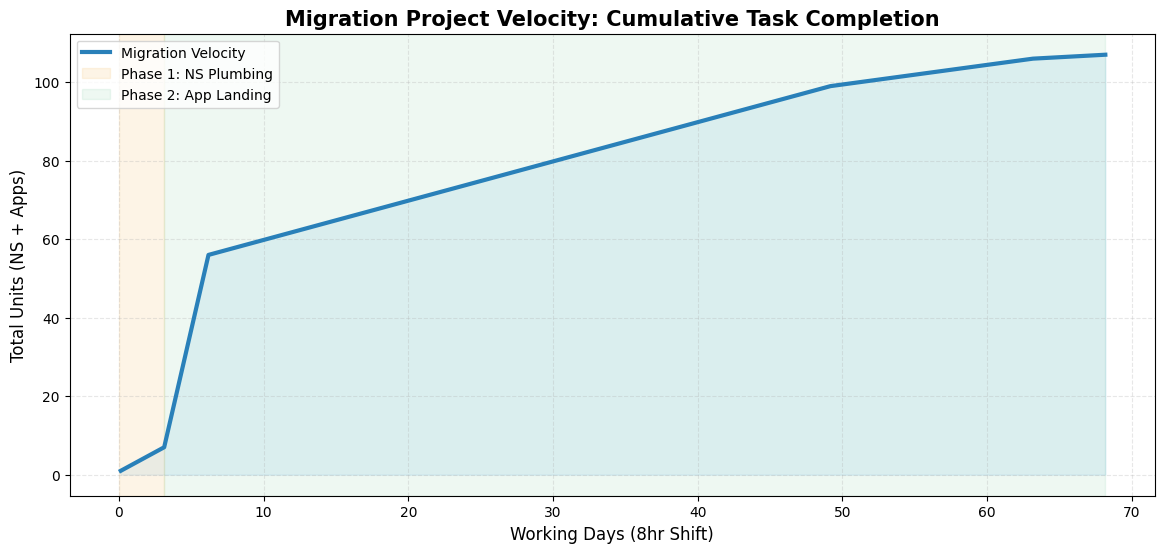


                CONSULTING ENGAGEMENT: MIGRATION SCOPE SUMMARY

[PHASE 1: WORKLOAD LANDING]
Tier         | Units    | Subtotal Hours 
----------------------------------------
Small        | 49       | 24.5           
Medium       | 43       | 344.0          
Large        | 7        | 112.0          
X-Large      | 1        | 40.0           

[PHASE 2: NAMESPACE PLUMBING]
Tier         | Units    | Subtotal Hours 
----------------------------------------
Small        | 1        | 1.0            
Medium       | 6        | 24.0           
Large        | 0        | 0.0            
X-Large      | 0        | 0.0            

GRAND TOTAL EFFORT: 545.5 Hours
ESTIMATED TIME (2 Engineers): 34.1 Working Days

Assumptions:
--------------
App Migrations:
1. Mature CI/CD in place.
2. Effort covers initial landing, connectivity and storage plumbing troubleshooting only.
3. Estimates for 'X-Large' include complex architectural remediation.


In [53]:
# --- 1. LINK TO YOUR ACTIVE DATAFRAMES ---
# If you have been using 'df' and 'ns_df' in your notebook:
df_wl = df    # Your Workload dataframe
df_ns = ns_df # Your Namespace dataframe

# --- 2. PREPARE COUNTS (Ensuring column names match) ---
# We use 'Complexity_TShirt' for workloads and 'NS_Complexity' for namespaces
wl_tiers = ['Small', 'Medium', 'Large', 'X-Large']
wl_counts = df_wl['Complexity_TShirt'].value_counts().reindex(wl_tiers, fill_value=0)
ns_counts = df_ns['NS_Complexity'].value_counts().reindex(wl_tiers, fill_value=0)

# --- 3. LOAD CONFIG FOR ESTIMATES ---
# Using the variable 'mig_cfg' we loaded earlier from migration_config.json
M_ESTIMATES = mig_cfg 

# --- 4. CALCULATE LINEAR EFFORT ---
ns_tasks = []
for tier in wl_tiers:
    ns_tasks.extend([tier] * int(ns_counts[tier]))

wl_tasks = []
for tier in wl_tiers:
    wl_tasks.extend([tier] * int(wl_counts[tier]))

# Map the hours from your config
# Note: Adjusting the keys to match your specific migration_config.json structure
all_efforts = [M_ESTIMATES["namespace_governance_estimates"].get(t, {}).get('hours', 0) for t in ns_tasks] + \
              [M_ESTIMATES["workload_migration_estimates"].get(t, {}).get('hours', 0) for t in wl_tasks]

# --- 5. GENERATE THE GRAPH ---
import numpy as np
import matplotlib.pyplot as plt

cumulative_hrs = np.cumsum(all_efforts)
project_days = cumulative_hrs / 8
task_indices = np.arange(1, len(all_efforts) + 1)

plt.figure(figsize=(14, 6))
plt.plot(project_days, task_indices, color='#2980b9', linewidth=3, label='Migration Velocity')
plt.fill_between(project_days, task_indices, color='#3498db', alpha=0.1)

# Add Phase Overlays
ns_end_day = project_days[len(ns_tasks)-1] if len(ns_tasks) > 0 else 0
plt.axvspan(0, ns_end_day, color='#f39c12', alpha=0.10, label='Phase 1: NS Plumbing')
plt.axvspan(ns_end_day, project_days[-1], color='#27ae60', alpha=0.08, label='Phase 2: App Landing')

plt.title('Migration Project Velocity: Cumulative Task Completion', fontsize=15, fontweight='bold')
plt.xlabel('Working Days (8hr Shift)', fontsize=12)
plt.ylabel('Total Units (NS + Apps)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


# --- 1. DATA PREP (Using your existing dataframes) ---
wl_tiers = ['Small', 'Medium', 'Large', 'X-Large']
wl_counts = df['Complexity_TShirt'].value_counts().reindex(wl_tiers, fill_value=0)
ns_counts = ns_df['NS_Complexity'].value_counts().reindex(wl_tiers, fill_value=0)

# --- 2. START THE PRINT SUMMARY ---
print("\n" + "="*80)
print("                CONSULTING ENGAGEMENT: MIGRATION SCOPE SUMMARY")
print("="*80)

# --- PHASE 1: WORKLOAD LANDING ---
print(f"\n[PHASE 1: WORKLOAD LANDING]")
print(f"{'Tier':<12} | {'Units':<8} | {'Subtotal Hours':<15}")
print("-" * 40)

total_wl_hrs = 0
for tier in wl_tiers:
    count = int(wl_counts[tier])
    # Pull hours from workload_migration_estimates in your mig_cfg
    hr_rate = mig_cfg['workload_migration_estimates'].get(tier, {}).get('hours', 0)
    subtotal = count * hr_rate
    total_wl_hrs += subtotal
    print(f"{tier:<12} | {count:<8} | {subtotal:<15,.1f}")

# --- PHASE 2: NAMESPACE PLUMBING ---
print(f"\n[PHASE 2: NAMESPACE PLUMBING]")
print(f"{'Tier':<12} | {'Units':<8} | {'Subtotal Hours':<15}")
print("-" * 40)

total_ns_hrs = 0
for tier in wl_tiers:
    count = int(ns_counts[tier])
    # Pull hours from namespace_governance_estimates in your mig_cfg
    hr_rate = mig_cfg['namespace_governance_estimates'].get(tier, {}).get('hours', 0)
    subtotal = count * hr_rate
    total_ns_hrs += subtotal
    print(f"{tier:<12} | {count:<8} | {subtotal:<15,.1f}")

# --- GRAND TOTALS ---
grand_total_hrs = total_wl_hrs + total_ns_hrs
engineers = 2
working_days = grand_total_hrs / (engineers * 8)

print("\n" + "="*80)
print(f"GRAND TOTAL EFFORT: {grand_total_hrs:,.1f} Hours")
print(f"ESTIMATED TIME ({engineers} Engineers): {working_days:,.1f} Working Days")
print("="*80)

print("\nAssumptions:")
print("--------------")
print("App Migrations:")
print("1. Mature CI/CD in place.")
print("2. Effort covers initial landing, connectivity and storage plumbing troubleshooting only.")
print("3. Estimates for 'X-Large' include complex architectural remediation.")
print("="*80)